# 1

In [3]:
from itertools import cycle

with open("1.txt") as f:
    data = [*map(int, f.readlines())]

print(sum(data))

frequencies = set()
x = 0
for value in cycle(data):
    x += value
    if x in frequencies:
        break
    else:
        frequencies.add(x)
print(x)

525
75749


# 2

In [6]:
from collections import Counter
from functools import reduce
from math import prod
from itertools import combinations

with open("2.txt") as f:
    s = f.read().split("\n")

matches = (0, 0)

for line in s:
    m = reduce(lambda acc, v: (acc[0] or v == 2, acc[1] or v == 3), Counter(line).values(), (0,0))
    matches = tuple(x + y for x, y in zip(m, matches))

print(prod(matches))

for a, b in combinations(s, 2):
    output = "".join(a[x]*(a[x] == b[x]) for x in range(len(a)))
    if len(output) == len(a) - 1:
        print(output)

5000
ymdrchgpvwfloluktajxijsqb


# 3

In [8]:
import numpy as np
import re

grid = np.zeros((1000, 1000), dtype="int")
pattern = r"#(\d+) @ (\d+),(\d+): (\d+)x(\d+)"

with open("3.txt") as f:
    data = [tuple(map(int, t)) for t in re.findall(pattern, f.read())]

for _, c, r, w, h in data:
    grid[r:r+h, c:c+w] += 1

mask = grid > 1
print(np.count_nonzero(mask))

for id, c, r, w, h in data:
    if np.all(~mask[r:r+h, c:c+w]):
         print(id)

107043
346


# 4

In [9]:
import re
import numpy as np
from math import prod

class Guard:
    def __init__(self, id):
        self.id = id
        self.starts = []
        self.ends = []

    def add(self, time, start=False):
        if start:
            self.starts.append(time)
        else:
            self.ends.append(time)

    def fill(self):
        row = np.zeros(60, dtype="int")
        if self.starts and self.ends:
            row[np.r_[tuple(slice(*r) for r in zip(self.starts, self.ends))]] = 1
        return self.id, row

with open("4.txt") as f:
    lines = sorted(f.readlines())

guards = {}
current_guard = None

for line in lines:
    if "Guard" in line:
        if current_guard is not None:
            id, row = current_guard.fill()
            guards[id] = np.vstack([guards[id], row])
        id = int(re.search(r"#(\d+) ", line).groups()[0])
        current_guard = Guard(id)
        guards[id] = guards.get(id, np.zeros((0, 60), dtype="int"))
    else:
        current_guard.add(int(re.search(r":(\d{2})]", line).groups()[0]), start="falls" in line)
id, row = current_guard.fill()
guards[id] = np.vstack([guards[id], row])

ID, GUARD = max(guards.items(), key=lambda x: np.count_nonzero(x[1]))
time = np.argmax(GUARD.sum(axis=0))
print(ID*time)

all_guards = []
for ID, GUARD in guards.items():
    all_guards.append((np.max(GUARD.sum(axis=0)), np.argmax(GUARD.sum(axis=0)), ID))
print(prod(sorted(all_guards, reverse=True)[0][1:]))

30630
136571


# 5

In [10]:
from string import ascii_uppercase as uc

with open("5.txt") as f:
    s = f.read()

def shrink(s):
    stack = []
    for c in s:
        if stack and stack[-1].lower() == c.lower() and stack[-1] != c:
            stack.pop()
        else:
            stack.append(c)
    return len(stack)

print(shrink(s))
print(min(shrink(s.replace(c, "").replace(c.lower(), "")) for c in uc))

9900
4992


# 6

In [11]:
import numpy as np
from string import ascii_letters as letters

def closest(distances, default="."):
    min_dist = min(distances.values())
    closest_letters = [c for c, dist in distances.items() if dist == min_dist]
    return closest_letters[0] if len(closest_letters) == 1 else default

def md(x1, y1, x2, y2):
    return abs(x1 - x2) + abs(y1 - y2)

with open("6.txt") as f:
    points = [tuple(map(int, x)) for x in re.findall(r"(\d+), (\d+)", f.read())]

size = (360, 360)
grid = np.full(size, " ", dtype="<U1")
part1 = np.full(size, " ", dtype="<U1")
part2 = np.full(size, " ", dtype="<U1")
for (x, y), letter in zip(points, letters):
    grid[x,y] = letter

for pos in np.ndindex(grid.shape):
    part1[pos] = closest({k:md(*pos, *p) for k, p in zip(letters, points)})
    part2[pos] = "X" if sum(md(*pos, *p) for p in points) < 10000 else " "

edges = set(np.concatenate([part1[0, :], part1[-1, :], part1[:, 0], part1[:, -1]]))
print(max(np.sum(part1 == c) for c in letters if c not in edges))
print(np.sum(part2 == "X"))

np.savetxt("6_grid.txt", part1, fmt="%s", delimiter="", newline="\n")

4754
42344


<div style="color: red; font-size: xx-large; font-weight: bold;">7</div>

In [45]:
from collections import defaultdict, deque
from string import ascii_uppercase as uc
import heapq
import re

with open("7.txt") as f:
    constraints = [(a, b) for a, b in re.findall(r"Step ([A-Z])[ a-z]+([A-Z])", f.read())]

graph = defaultdict(list)
deps = {v: 0 for v in uc}
ordered = []

for small, large in constraints:
    graph[small].append(large)
    deps[large] += 1

heap = [v for v in uc if deps[v] == 0]
heapq.heapify(heap)
while heap:
    node = heapq.heappop(heap)
    ordered.append(node)
    for neighbor in graph[node]:
        deps[neighbor] -= 1
        if deps[neighbor] == 0:
            heapq.heappush(heap, neighbor)

print("".join(ordered))

#part 2 ord() + 20

ADEFKLBVJQWUXCNGORTMYSIHPZ


# 8

In [47]:
with open("8.txt") as f:
    s = f.read()

class Node:
    def __init__(self, c, m):
        self.c = [Node(next(stream), next(stream)) for _ in range(c)]
        self.m = [next(stream) for _ in range(m)]

    def get1(self):
        return sum(self.m) + sum(c.get1() for c in self.c)

    def get2(self):
        if self.c:
            return sum(self.c[x-1].get2()if x-1 in range(len(self.c))else 0 for x in self.m)
        return sum(self.m)

stream = map(int, s.split())
parent = Node(next(stream), next(stream))

print(parent.get1())
print(parent.get2())

46781
21405


# 9

In [48]:
import re
from collections import deque

s = "448 players; last marble is worth 71628 points"

def play(players, last_marble):
    circle = deque([0])
    scores = [0] * players
    for marble in range(1, last_marble + 1):
        p = (marble - 1) % players
        if marble % 23 == 0:
            circle.rotate(7)
            scores[p] += marble + circle.pop()
            circle.rotate(-1)
        else:
            circle.rotate(-1)
            circle.append(marble)
    return max(scores)

P, M = map(int, re.findall(r"(\d+)", s))

print(play(P, M))
print(play(P, M*100))

394486
3276488008


# 10

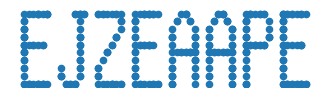

10054


In [52]:
from itertools import islice
import matplotlib.pyplot as plt
import re

class Point:
    def __init__(self, **kwargs):
        vars(self).update(kwargs)
    def update(self):
        self.x += self.dx
        self.y += self.dy

def get_box_size(points):
    x_coords, y_coords = zip(*[(p.x, p.y) for p in points])
    width = max(x_coords) - min(x_coords)
    height = max(y_coords) - min(y_coords)
    return width, height

def batched(iterable, n):
    it = iter(iterable)
    while (batch := list(islice(it, n))):
        yield batch

with open("10.txt") as f:
    nums = batched(map(int, re.findall(r"-?\d+", f.read())), n=4)
    points = [Point(x=x, y=y, dx=dx, dy=dy) for x, y, dx, dy in nums]

i = 0
while True:
    height1, width1 = get_box_size(points)
    points2 = [Point(x=p.x+p.dx, y=p.y+p.dy, dx=p.dx, dy=p.dy) for p in points]
    height2, width2 = get_box_size(points2)
    if height2 > height1:
        break
    i += 1
    for p in points:
        p.update()

plt.figure(figsize=(4, 1))
plt.scatter(*zip(*[(p.x, p.y) for p in points]), s=20)
plt.gca().invert_yaxis()
plt.axis('off')
plt.show()
print(i)

# 11

In [6]:
import numpy as np

S = 7511

ys, xs = np.indices((300, 300))
X, Y = xs + 1, ys + 1
grid = (((X + 10) * Y + S) * (X + 10) // 100 % 10) - 5

largest = [0, 0, 0]

for N in range(2, 300):
    blocks = np.zeros((grid.shape[0] - N + 1, grid.shape[1] - N + 1), dtype=int)
    for dy in range(N):
        for dx in range(N):
            blocks += grid[dy:dy+blocks.shape[0], dx:dx+blocks.shape[1]]

    y, x = np.unravel_index(np.argmax(blocks), blocks.shape)
    if N == 3:
        print(f"{x + 1},{y + 1}")
    if blocks[y, x] < largest[0]:
        print(f"{largest[1]},{largest[2]},{N - 1}")
        break
    largest = [blocks[y, x], x + 1, y + 1, N]

21,22
235,288,13


# 12

In [7]:
from collections import Counter
import re
import numpy as np

with open("12.txt") as f:
    contents = f.read()

state = re.search(r"[.#]{6,}", contents).group(0)
lookups = {a: b for a, b in re.findall(r"([.#]{5}) => ([.#])", contents)}
grid = np.array(list(f"..{state}" + "."*len(state)))

counts = Counter()
offset = last = change = 0
first_gen = None

for g in range(100):
    pattern = "".join(grid).strip(".")
    counts[pattern] += 1
    if counts[pattern] == 2:
        offset = g - 1
        change = pattern.count("#")
        indices = np.where(grid == "#")[0] - 2
        last = indices.sum() - change
        break

    padded_grid = np.pad(grid, (0, 4), constant_values=".")
    next_grid = padded_grid.copy()
    if g == 20:
        first_gen = padded_grid.copy()
    for i in range(2, len(padded_grid) - 2):
        next_grid[i] = lookups.get("".join(padded_grid[i-2:i+3]), ".")
        
    grid = next_grid[:np.where(next_grid == "#")[0][-1] + 1]

part1 = np.where(first_gen == "#")[0] - 2
print(part1.sum())

print(last + change*(50000000000 - offset))

1787
1100000000475


# 13

In [10]:
import numpy as np
from itertools import cycle

class Cart:
    DIRS = {"^": (-1, 0), "v": (1, 0), "<": (0, -1), ">": (0, 1)}
    TURN = {
        "L": {"^": "<", "v": ">", "<": "v", ">": "^"}, 
        "S": {"^": "^", "v": "v", "<": "<", ">": ">"},
        "R": {"^": ">", "v": "<", "<": "^", ">": "v"}}
    
    def __init__(self, y, x, shape):
        self.y = y
        self.x = x
        self.shape = shape
        self.turns = cycle("LSR")
        self.next_turn = next(self.turns)
        
    def update(self, carts):
        dy, dx = self.DIRS[self.shape]
        self.y += dy
        self.x += dx
        track_marker = track[self.y, self.x]
        if track_marker == "+":
            self.shape = self.TURN[self.next_turn][self.shape]
            self.next_turn = next(self.turns)
        elif track_marker == "/":
            self.shape = self.TURN["L" if self.shape in "<>" else "R"][self.shape]
        elif track_marker == "\\":
            self.shape = self.TURN["R" if self.shape in "<>" else "L"][self.shape]
        for i, c in enumerate(carts):
            if (self.y, self.x) == (c.y, c.x) and self is not c:
                return (self.y, self.x), i
        return None, 0

with open("13.txt") as f:
    data = f.read()
    
track = np.array([list(d) for d in data.split("\n")], dtype="<U1")
carts = [Cart(y, x, track[y, x]) for y, x in zip(*np.where(np.isin(track, ["v", "^", "<", ">"])))]
mapping = {"^": "|", "v": "|", ">": "-", "<": "-"}
track = np.vectorize(lambda x: mapping.get(x, x))(track)
C = len(carts)

while len(carts) > 1:
    bangs = []
    carts.sort(key=lambda c: (c.y, c.x))
    for i, c in enumerate(carts):
        if i in bangs: continue
        location, partner = c.update(carts)
        if location is not None:
            # Print Part 1: first collision
            if len(carts) == C: print("{},{}".format(*location[::-1]))
            bangs.extend([i, partner])
    carts = [c for i, c in enumerate(carts) if i not in bangs]

print(f"{carts[0].x},{carts[0].y}")

32,8
38,38


# 14

In [4]:
s = "702831"
target = [int(c) for c in s]
size_s = len(target)
int_s = int(s)

recipes = [3, 7]
a, b = 0, 1
offset = 0

while True:
    total = recipes[a] + recipes[b]
    if total >= 10:
        recipes.append(total // 10)
    recipes.append(total % 10)
    a = (a + recipes[a] + 1) % len(recipes)
    b = (b + recipes[b] + 1) % len(recipes)

    if recipes[-size_s:] == target:
        break
    if recipes[-size_s-1:-1] == target:
        offset = 1
        break

print("".join(map(str, recipes[int_s:int_s + 10])))
print(len(recipes) - size_s - offset)

1132413111
20340232


# 15

# 16

# 17

In [200]:
import numpy as np
import re
from numba import jit

DOT = np.int8(0) # '.'
WAL = np.int8(1) # '#'
SRC = np.int8(2) # '+'
FLO = np.int8(3) # '|'
WAT = np.int8(4) # '~'

@jit
def flow(y, x, grid):
    # Down until stop
    while y + 1 < grid.shape[0] and grid[y + 1, x] in (DOT, FLO):
        grid[y, x] = FLO
        y += 1
    if y + 1 == grid.shape[0]:
        grid[y, x] = FLO
        return
    
    # Spread L & R
    left = x
    while grid[y, left - 1] in (DOT, FLO) and grid[y + 1, left] in (WAL, WAT):
        left -= 1
        grid[y, left] = FLO
    right = x
    while grid[y, right + 1] in (DOT, FLO) and grid[y + 1, right] in (WAL, WAT):
        right += 1
        grid[y, right] = FLO
    
    # Check wall to wall below
    if grid[y + 1, left] in (WAL, WAT) and grid[y + 1, right] in (WAL, WAT):
        grid[y, left:right + 1] = WAT
        flow(y - 1, x, grid)
    else:
        if grid[y + 1, left] in (DOT, FLO):
            flow(y, left, grid)
        if grid[y + 1, right] in (DOT, FLO):
            flow(y, right, grid)

with open("17.txt") as f:
    txt = f.read()

xs = []
ys = []
pattern = r"(?:x=(?P<x1>[\d\.]+), y=(?P<y1>[\d\.]+))|" \
          r"(?:y=(?P<y2>[\d\.]+), x=(?P<x2>[\d\.]+))"

for line in txt.split("\n"):
    if (m := re.search(pattern, line)):
        x = m.group("x1") or m.group("x2")
        y = m.group("y1") or m.group("y2")
        if ".." in x:
            x = x.split("..")
            xs.append(slice(int(x[0]), int(x[1]) + 1))
        else:
            xs.append(int(x))
        if ".." in y:
            y = y.split("..")
            ys.append(slice(int(y[0]), int(y[1]) + 1))
        else:
            ys.append(int(y))

minX = m if isinstance((m := min(xs, key=lambda x: x if isinstance(x, int) else x.start)), int) else m.start
maxX = m if isinstance((m := max(xs, key=lambda x: x if isinstance(x, int) else x.stop)), int) else m.stop
minY = m if isinstance((m := min(ys, key=lambda y: y if isinstance(y, int) else y.start)), int) else m.start
maxY = m if isinstance((m := max(ys, key=lambda y: y if isinstance(y, int) else y.stop)), int) else m.stop

grid = np.full((maxY + 1, maxX + 2), DOT)
source = (0, (maxX - minX)//2 + minX)
grid[source] = SRC
for pos in zip(ys, xs):
    grid[pos] = WAL

flow(*source, grid)

print(np.count_nonzero(np.isin(grid[minY:maxY + 1, :], [WAT, FLO])))
print(np.count_nonzero(grid[minY:maxY + 1, :] == WAT))

30495
24899


# 18

In [2]:
import numpy as np
from scipy.signal import convolve2d

OFF = ((-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1))

def minute(g):
    K = np.ones((3,3), dtype=int)
    K[1,1] = 0
    t_count = convolve2d((g == "|"), K, mode="same")
    l_count = convolve2d((g == "#"), K, mode="same")
    new_grid = g.copy()
    new_grid[(g == ".") & (t_count >= 3)] = "|"
    new_grid[(g == "|") & (l_count >= 3)] = "#"
    new_grid[(g == "#") & ((l_count == 0) | (t_count == 0))] = "."
    return new_grid

with open("18.txt") as f:
    grid = np.array([list(line.strip()) for line in f.readlines()])

seen = {}
start = length = 0

for i in range(1000):
    grid_key = "".join(grid.flatten().astype(str))
    if grid_key in seen:
        start = seen[grid_key]
        length = i - start
        break
    seen[grid_key] = i
    grid = minute(grid)

target = (1_000_000_000 - start) % length + start

for k, v in seen.items():
    if v == 10:
        g = np.array(list(k)).reshape(grid.shape)
        print(np.count_nonzero(g == "|") * np.count_nonzero(g == "#"))
    if v == target:
        g = np.array(list(k)).reshape(grid.shape)
        print(np.count_nonzero(g == "|") * np.count_nonzero(g == "#"))

583426
169024


# 19

# 20

# 21

# 22

In [18]:
import re
import heapq
import numpy as np

lookup = {
    0: {0: 8, 1: 1, 2: 1},
    1: {0: 1, 1: 8, 2: 1},
    2: {0: 1, 1: 1, 2: 8},
}

def dijkstra(grid, start, goal, item=1):
    rows, cols = grid.shape
    distances = np.full((rows, cols, 3), float("inf"))
    distances[start + (item,)] = 0
    q = [(0, *start, item)]
    valid = {0: {1, 2}, 1: {0, 2}, 2: {0, 1}}

    while q:
        cost, r, c, tool = heapq.heappop(q)
        if (r, c) == goal and tool == 1:
            return cost
        if cost > distances[r, c, tool]:
            continue
        for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols:
                new_type = grid[nr, nc]
                if tool in valid[new_type]:
                    move_cost = cost + 1
                    if move_cost < distances[nr, nc, tool]:
                        distances[nr, nc, tool] = move_cost
                        heapq.heappush(q, (move_cost, nr, nc, tool))
        current_type = grid[r, c]
        for t in valid[current_type] - {tool}:
            switch_cost = cost + 7
            if switch_cost < distances[r, c, t]:
                distances[r, c, t] = switch_cost
                heapq.heappush(q, (switch_cost, r, c, t))
    return 0

s = "depth: 8787\ntarget: 10,725"
D, X, Y = map(int, re.findall(r"\d+", s))
T = (Y, X)
H, W = Y + 20, X + 20

grid = np.zeros((H, W), dtype=np.int64)
grid[:, 0] = (48271*np.arange(H) + D) % 20183
grid[0, :] = (16807*np.arange(W) + D) % 20183
for i in range(1, H):
    for j in range(1, W):
        grid[i, j] = (grid[i, j-1] * grid[i-1, j] + D) % 20183
grid = grid%3
grid[T] = 0

print(np.sum(grid[:Y + 1, :X + 1]))
print(dijkstra(grid, (0, 0), T))

8090
992


# 23

In [19]:
import re
import numpy as np

class NB:
    def __init__(self, **kwargs):
        vars(self).update(kwargs)
        
    def compare(self, other):
        return abs(self.x - other.x) + abs(self.y - other.y) + abs(self.z - other.z)
    
    def get_in_range(self, nanobots):
        self.in_range = []
        for n in nanobots:
            if self.compare(n) <= self.r:
                self.in_range.append(n)
        
    def __lt__(self, other):
        return self.r < other.r
    
    def __repr__(self):
        return f"NanoBot(pos {self.x},{self.y},{self.z} r={self.r})"

def normalize():
    minx = min(n.x for n in nanobots)
    miny = min(n.y for n in nanobots)
    minz = min(n.z for n in nanobots)
    for n in nanobots:
        n.x += abs(minx)
        n.y += abs(miny)
        n.z += abs(minz)
    
nanobots = []
with open("23.txt") as f:
    for data in re.findall(r"<(-?\d+),(-?\d+),(-?\d+)>, r=(\d+)", f.read()):
        x, y, z, r = map(int, data)
        nanobots.append(NB(x=x, y=y, z=z, r=r))

normalize()
nanobots.sort(reverse=True)
biggest = nanobots[0]
biggest.get_in_range(nanobots)

print(len(biggest.in_range))


164


# 24

In [101]:
import re

class Army:
    def __init__(self, name, units):
        self.name = name
        self.units = units
        
    def is_vanquished(self):
        return len(self.units) == 0
    
    def sort(self):
        self.units.sort(reverse=True)
        
    def __repr__(self):
        return "\n\t" + "\n\t".join(f"{unit}" for unit in self.units)

class Unit:
    def __init__(self, n, hp, immune1, weak1, weak2, immune2, atk, atk_type, init):
        self.n = int(n)
        self.hp = int(hp)
        self.immune = (immune1 or immune2 or "").split(", ")
        self.weak = (weak1 or weak2 or "").split(", ")
        self.atk = int(atk)
        self.atk_type = atk_type
        self.init = int(init)
        self.effect = self.get_effect()
        
    def get_effect(self):
        self.effect = self.n * self.atk
        return self.effect
        
    def scout(self, army):
        for unit in army:
            if self.atk_type in unit.immune:
                continue
            ...
    
    def attack(self, opp):
        pass
    
    def __lt__(self, other):
        return (self.get_effect(), self.init) < (other.get_effect(), other.init)
        
    def __repr__(self):
        return (
            f"Unit( Effect: {self.effect:5} --- Size: {self.n:4}  HP: {self.hp:5}  "
            f"INIT: {self.init:2}  ATTACK: {self.atk:4}  TYPE: {self.atk_type:<11}  "
            f"IMMUNE: {','.join(self.immune):<20}  WEAK: {','.join(self.weak):<20} )"
        )
        
with open("24.txt") as f:
    hero, villian = f.read().split("\n\n")

battlefield = {}
pattern = (
    r"(\d+).*?(\d+)(?: .*?\((?:immune to ([\w, ]+)(?:; )?(?:weak to ([\w, ]+))?|" +
    r"weak to ([\w, ]+)(?:; )?(?:immune to ([\w, ]+))?)\))?.*?(\d+) (\w+).*?(\d+)"
)
rx = re.compile(pattern)

for name, txt in zip(("ImmuneSys", "Infection"), (hero, villian)):
    units = []
    for line in txt.splitlines()[1:]:
        stats = rx.search(line).groups()
        units.append(Unit(*stats))
    battlefield[name] = Army(name, units)
    battlefield[name].sort()
battlefield

{'ImmuneSys': 
 	Unit( Effect: 85086 --- Size:  326  HP:  9157  INIT:  6  ATTACK:  261  TYPE: radiation    IMMUNE:                       WEAK: cold,slashing        )
 	Unit( Effect: 78242 --- Size: 2698  HP:  9598  INIT: 16  ATTACK:   29  TYPE: slashing     IMMUNE: slashing              WEAK:                      )
 	Unit( Effect: 77435 --- Size: 4555  HP:  9688  INIT:  1  ATTACK:   17  TYPE: radiation    IMMUNE: radiation             WEAK: bludgeoning          )
 	Unit( Effect: 73234 --- Size: 5231  HP:  8051  INIT:  9  ATTACK:   14  TYPE: radiation    IMMUNE:                       WEAK: radiation            )
 	Unit( Effect: 60866 --- Size: 4682  HP:  6161  INIT: 19  ATTACK:   13  TYPE: radiation    IMMUNE:                       WEAK:                      )
 	Unit( Effect: 43884 --- Size:   53  HP:  5147  INIT: 11  ATTACK:  828  TYPE: cold         IMMUNE: bludgeoning,slashing  WEAK:                      )
 	Unit( Effect: 42240 --- Size:  704  HP:  4351  INIT:  2  ATTACK:   60  TYPE: 

In [59]:
len(pattern)

149